<a href="https://colab.research.google.com/github/saneeshaparna39-dotcom/ML-assignment/blob/main/CIFAR_10_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.cifar10.load_data()
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 426s 2us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [ ]:
num_class = len(np.unique(y_train))
print("number of classes: {num_class}")
print("class labels:",np.unique(y_train))

number of classes: {num_class}
class labels: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
x_train.shape

(50000, 32, 32, 3)

In [ ]:
x_test.shape

(10000, 32, 32, 3)

In [ ]:
y_train.shape

(50000, 1)

In [ ]:
y_test.shape

(10000, 1)

In [ ]:
print("shape of a single image(x_train[100]):",x_train[100].shape)

shape of a single image(x_train[100]): (32, 32, 3)


In [ ]:
x_train,x_test=x_train/255.0,x_test/255.0

In [ ]:
y_train=y_train.flatten()
y_test=y_test.flatten()

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat','deer',
               'dog','frog','horse','ship','truck']

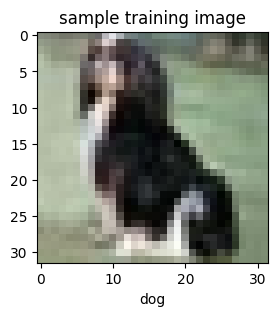

In [ ]:
def plot_sample(x,y,index):
 plt.figure(figsize=(3,3))
 plt.imshow(x[index])
 plt.xlabel(class_names[y[index]])
 plt.title("sample training image")
 plt.show()
plot_sample(x_train,y_train,339)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model=tf.keras.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(x_train,y_train,epochs=10,
                    validation_data=(x_test,y_test),batch_size=64)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 86ms/step - accuracy: 0.3254 - loss: 1.8117 - val_accuracy: 0.4627 - val_loss: 1.4318
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.4785 - loss: 1.4460 - val_accuracy: 0.5604 - val_loss: 1.2151
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 88ms/step - accuracy: 0.5349 - loss: 1.3075 - val_accuracy: 0.5904 - val_loss: 1.1454
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 98ms/step - accuracy: 0.5727 - loss: 1.2156 - val_accuracy: 0.6028 - val_loss: 1.1443
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 97ms/step - accuracy: 0.6036 - loss: 1.1395 - val_accuracy: 0.6333 - val_loss: 1.0564
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 76s 97ms/step - accuracy: 0.6246 - loss: 1.0814 - val_accuracy: 0.6637 - val_loss: 0.9659
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 94ms/step - accuracy: 0.6430 - loss: 1.0266 - val_accuracy: 0.6638 - val_loss: 0.9568
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 97ms/step - accuracy: 0.6585 - loss: 0.9806 - 

In [ ]:
test_loss,test_accuracy = model.evaluate(x_test,y_test)
print("test accuracy:",test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6850 - loss: 0.9149
test accuracy: 0.6850000023841858


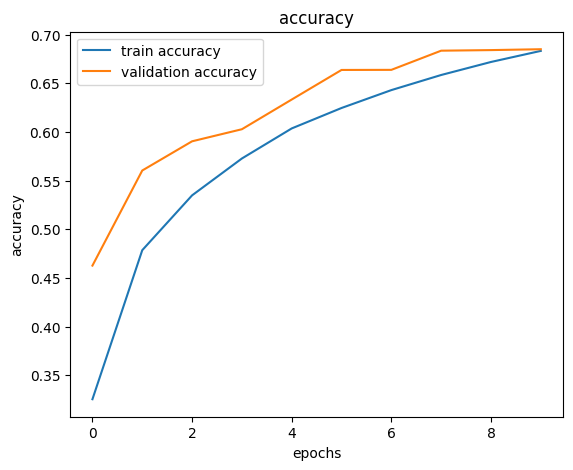

In [ ]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'],label='train accuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.title('accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.legend()

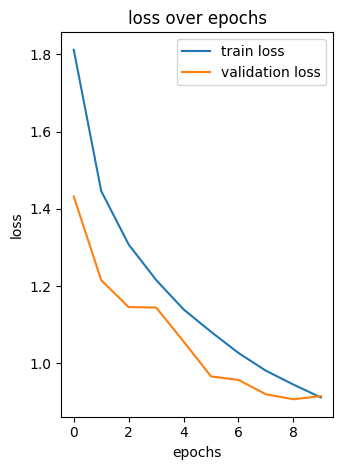

In [ ]:
import matplotlib.pyplot as plt
plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='train loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.title('loss over epochs')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
y_pred_probs = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


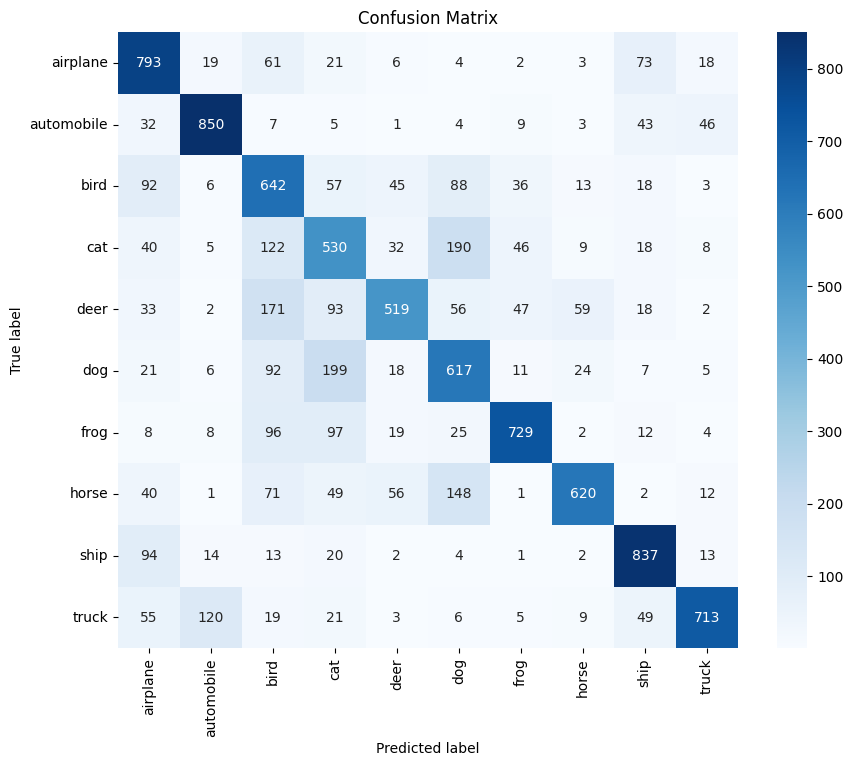

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

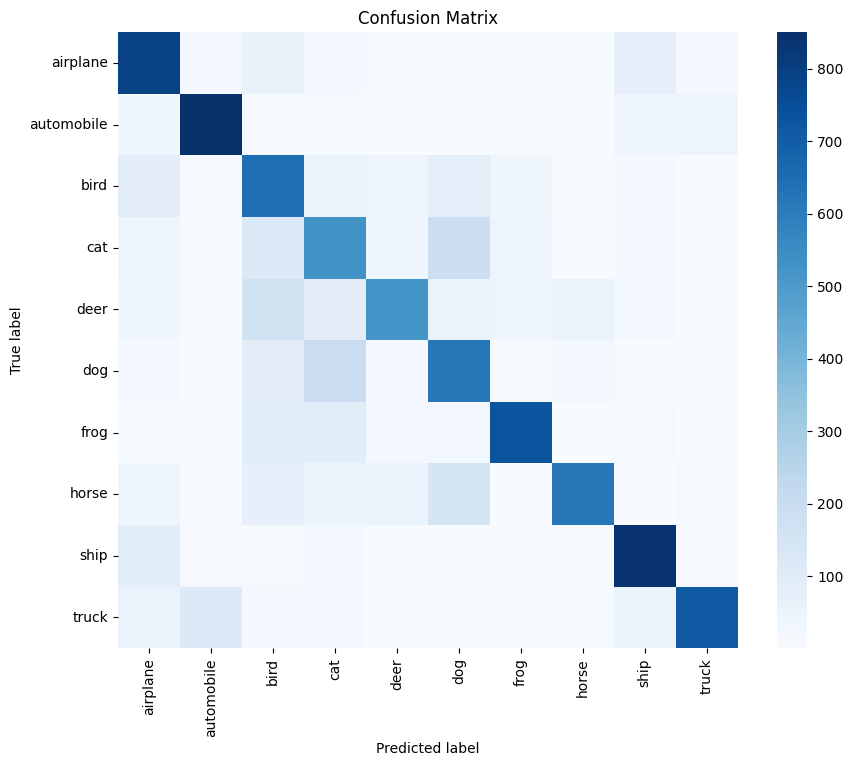

In [ ]:
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

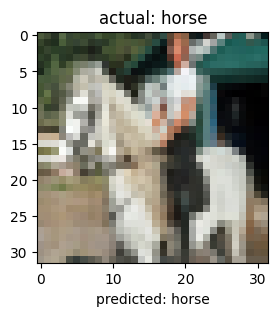

In [ ]:
index = 56
plt.figure(figsize=(3,3))
plt.imshow(x_test[index])
plt.title(f'actual: {class_names[y_test[index]]}')
plt.xlabel(f'predicted: {class_names[y_pred_classes[index]]}')
plt.show()